In [1]:
include("../src/main.jl");

In [2]:
dump_filepath = "../src/models/iharm3dDumps/dump_001.h5";

In [3]:
#TODO: put this in reading file
N1 = 128
N2 = 64
N3 = 32

trat_large = 20. #TODO: prob have to be read from file
trat_small = 1. #TODO: prob have to be read from file
beta_crit = 1.0 #TODO: prob have to be read from file
game = (4. /3.)  # Ion adiabatic index  TODO: prob have to be read from file
gamp = (5. /3.)  # Electron adiabatic index TODO: prob have to be read from file
gam = (13. /9.)  # Total adiabatic index TODO: prob have to be read from file
Ne_factor = 1.0  # Scaling factor for electron number density TODO: prob have to be read from file
rmin_geo = 1.001875757988324 #TODO: Has to be read from file as Rin and compared to the value chosen
rmax_geo = 100. #TODO: Has to be read from file as Rin and compared to the value chosen
th_beg = 1.74e-2 #TODO: Idk where this comes from, check ipole source code
sigma_cut = 1.0 #TODO: maybe put it somewhere else?
sigma_cut_high = -1.0
startx::MVec4 = [0, 1.874000951149813e-03, 0, 0]#TODO: prob have to be read from file
stopx::MVec4 = [1, 6.907755278982138e+00, 1, 2 * π]#TODO: prob have to be read from file
dx::MVec4 = [0, 5.395219748461709e-02, 1.562500000000000e-02, 1.963495408493621e-01] #TODO: prob have to be read from file
bhspin = 0.9375 #TODO: prob have to be read from file
hslope = 0.3 #TODO: prob have to be read from file
simulation_data = load_data(dump_filepath);

Loading data from '../src/models/iharm3dDumps/dump_001.h5' into 'iharm' module...
Using mixed tp_over_te with trat_small = 1.0, trat_large = 20.0, and beta_crit = 1.0
data_array: 870.0546975445741
B_unit: 66.4216771242051
All primitives successfully loaded. Dimensions: (128, 64, 32)


In [4]:
#Analytic parameters

#Setting up the parameters
#Observer distance in Rg
ro = 1000.0
#Observer inclination in degrees
th = 17.0

#Observer azimuth in degrees
phi = 0.0

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
res = 40
pixels_x = 40
pixels_y = 40
# Distance to the source in parsecs
SourceD = 16.9e6 * PC
Rout = 1000.0
Rstop = 100.0
Rh = 1 + sqrt(1. - bhspin * bhspin);

#Check if these are correct
cstartx = [0.0, log(Rh), 0.0, 0.0]#TODO: prob have to be read from file
cstopx = [0.0, log(1000.0), 1.0, 2.0 * π]#TODO: prob have to be read from file

# Frequency observed by the camera in Hz
freq = 230e9;

# Size of the screen in Rg in both directions
DXsize = SourceD/L_unit/MUAS_PER_RAD * 160
DYsize = SourceD/L_unit/MUAS_PER_RAD * 160
# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
fovx = DXsize/ro
fovy = DYsize/ro
xoff = 0.0
yoff = 0.0


0.0

In [ ]:
#TODO: Ipole and Jipole are not matching geodesics perfectly to 15 decimals (it could be an effect of get_connection)
include("../src/main.jl");
# Find camera in native coordinates
Xcamera = MVec4(camera_position(ro, th, phi, bhspin, Rout))

# Scales the intensity of each pixel by the real size of each pixel
scale_factor = CalculateScaleFactor(DXsize, DYsize, pixels_x, pixels_y, SourceD, L_unit)
println("scale_factor = $scale_factor")
maxnstep = 15000
# Generate geodesics
println("Utilizing $(Threads.nthreads()) threads for geodesic calculation.")
freq_unitless = freq * HPL/(ME * CL * CL)  # Convert frequency to unitless
Image = zeros(Float64, pixels_x, pixels_y)
for i in 0:(pixels_x - 1)
    println("Processing row $i out of $(pixels_x)")

    Threads.@threads for j in 0:(pixels_y - 1)
        traj = Vector{OfTraj}()
        sizehint!(traj, maxnstep)

        nstep = get_pixel(traj, i, j, Xcamera, maxnstep, fovx, fovy, freq_unitless, pixels_x, pixels_y, bhspin, Rh, Rout, Rstop, xoff, yoff)

        resize!(traj, length(traj))
        integrate_emission!(traj, length(traj), Image, i + 1, j + 1, freq, bhspin, simulation_data)

    end
end
Image *= freq^3;

scale_factor = 37.6070182109265
Utilizing 8 threads for geodesic calculation.
Processing row 0 out of 40
At step 679, Intensity = 4.867371462442992e-41
At step 678, Intensity = 1.4643345044950153e-40
At step 677, Intensity = 2.4501469714094474e-40
At step 676, Intensity = 3.4440455194871317e-40
At step 675, Intensity = 4.4461942828508876e-40
At step 674, Intensity = 5.457225980490246e-40
At step 673, Intensity = 6.477554641264105e-40
At step 672, Intensity = 7.507206855619058e-40
At step 671, Intensity = 8.546216687086885e-40
At step 670, Intensity = 9.594626857951498e-40
At step 669, Intensity = 1.0652490049260734e-39
At step 668, Intensity = 1.171987032067402e-39
At step 667, Intensity = 1.2796844655398426e-39
At step 666, Intensity = 1.388350463520462e-39
At step 665, Intensity = 1.4979958249946066e-39
At step 664, Intensity = 1.6086331845803845e-39
At step 663, Intensity = 1.7202853839792562e-39
At step 662, Intensity = 1.8329613935944757e-39
At step 661, Intensity = 1.946620851748

In [6]:
OutputStokesParameters(Image, freq, scale_factor, res, SourceD)

Image processing complete. Calculating total flux and averages...
Scale = 3.760701821092650e+01
imax = 40, jmax = 40, Imax = 0.0011728489747050582, Iavg = 0.0010844797125230173
Using freq_cgs = 2.3e11, Ftot = 65.25447727717336
nuLnu = 5.1288811169396616e42


In [8]:
using DelimitedFiles

writedlm("./Image.txt", Image)


In [ ]:
using DelimitedFiles

Image_loaded = readdlm("./Image.txt")


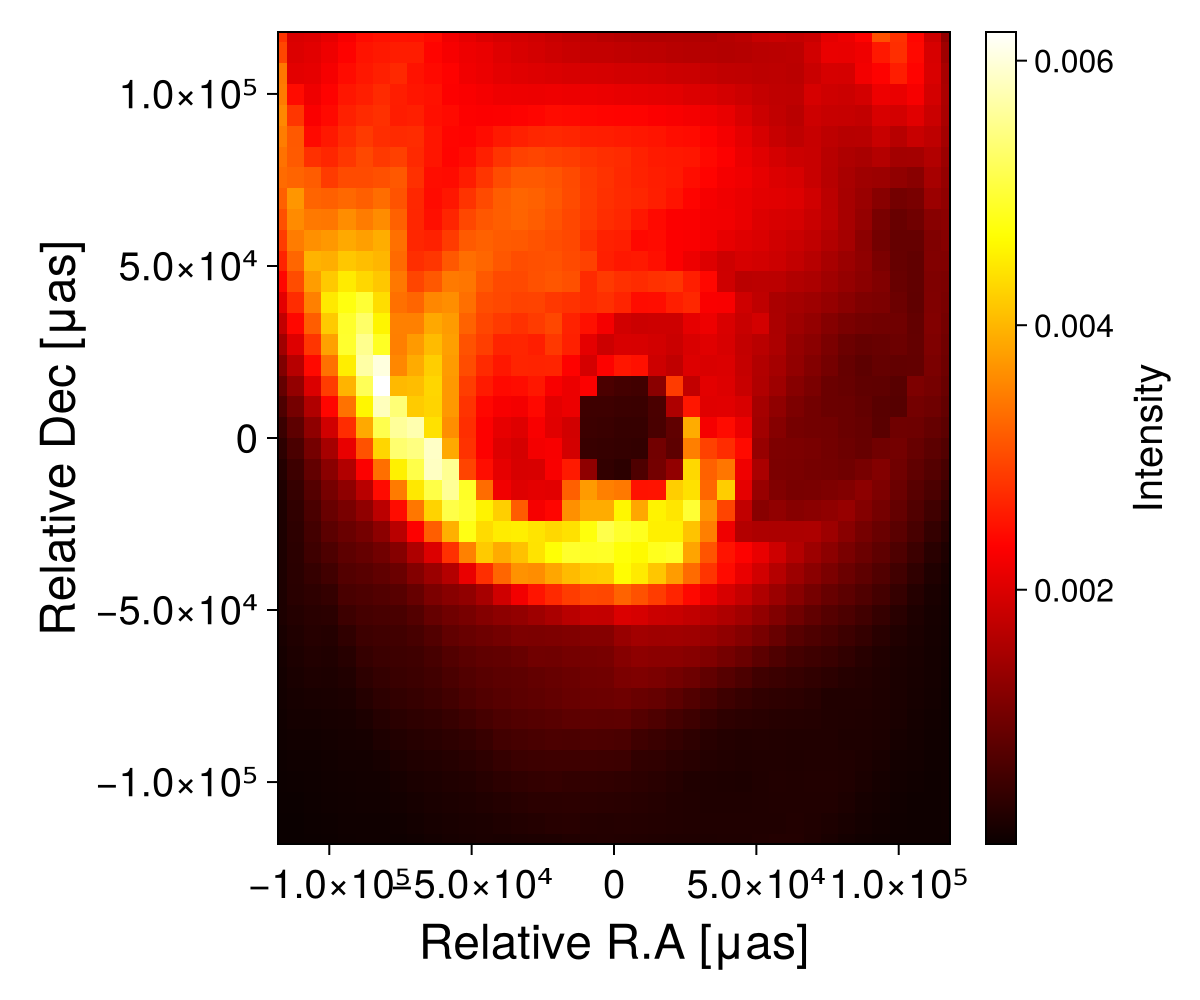

In [9]:
using CairoMakie
using Printf

d_kpc = 7.78
d_cm = d_kpc * 3.086e21           # distance in cm
fov_rg = 30                       # field of view in gravitational radii
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm   # half FOV in radians
theta_μas = theta_rad * MUAS_PER_RAD        # convert to μas
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

# Generate mock image (or load your 128x128 array here)
img = Image

# Axes
Ny, Nx = size(img)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

# Plot
fig = Figure(size = (600, 500))
ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims)
)

# Heatmap with color range
crange = extrema(img)
hm = heatmap!(ax, x, y, img; colormap=:hot, colorrange=crange)

# Colorbar
Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig


In [6]:
# From Ipole

In [12]:
using HDF5

function load_ipole_unpol(fname)
    hfp = h5open(fname, "r") do file
        # Read values
        dx = read(file["header/camera/dx"])
        dsource = read(file["header/dsource"])
        lunit = read(file["header/units/L_unit"])
        scale = read(file["header/scale"])

        fov_muas = dx / dsource * lunit * 2.06265e11

        # evpa_0 might not exist
        evpa_0 = haskey(file["header"], "evpa_0") ? read(file["header/evpa_0"]) : "W"

        # Load and transpose unpol
        unpol = read(file["unpol"])
        unpol_t = permutedims(unpol, (2,1))

        return unpol_t, fov_muas, scale, evpa_0
    end

    return hfp
end

load_ipole_unpol (generic function with 1 method)

In [13]:
Image1, _, _, _= load_ipole_unpol("../../ipole/image.h5")

([8.233421941705342e-5 8.521815581569922e-5 … 0.0020205738150697056 0.0016852612368673543; 7.753977831356059e-5 8.276657275500758e-5 … 0.000788815964249771 0.0006846818425350721; … ; 0.00011429092296199376 0.00011686607621426469 … 0.0014757403048885089 0.0013350815276502342; 0.00011956884484868792 0.0001228642228144521 … 0.0010126581520189663 0.0008398516209955787], 160.0, 37.6070182109265, "N")

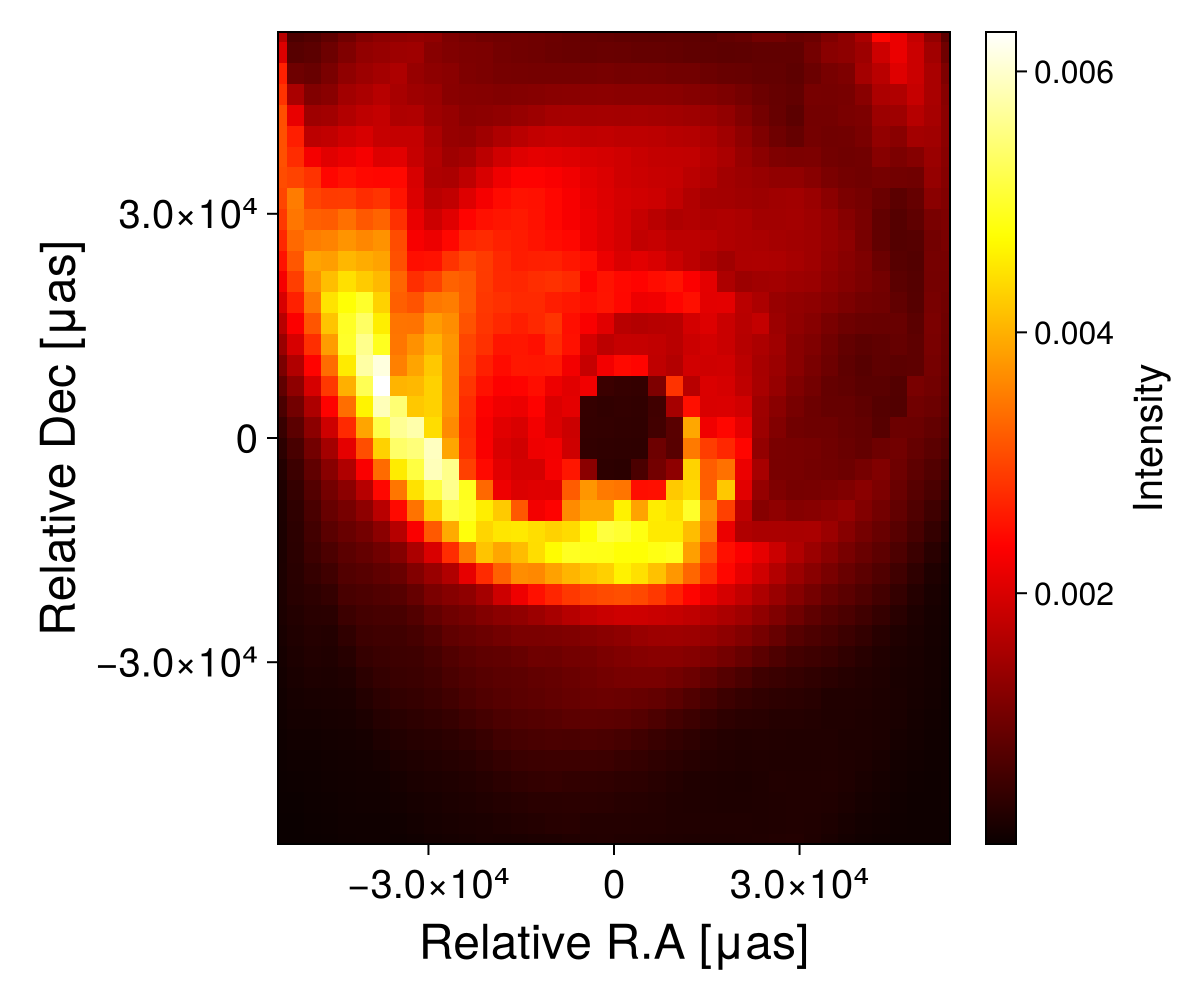

In [14]:
using CairoMakie
using Printf

d_kpc = 16.9
d_cm = d_kpc * 3.086e21           # distance in cm
fov_rg = 30                       # field of view in gravitational radii
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm   # half FOV in radians
theta_μas = theta_rad * MUAS_PER_RAD        # convert to μas
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

# Generate mock image (or load your 128x128 array here)
img = Image1

# Axes
Ny, Nx = size(img)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

# Plot
fig = Figure(size = (600, 500))
ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims)
)

# Heatmap with color range
crange = extrema(img)
hm = heatmap!(ax, x, y, img; colormap=:hot, colorrange=crange)

# Colorbar
Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig


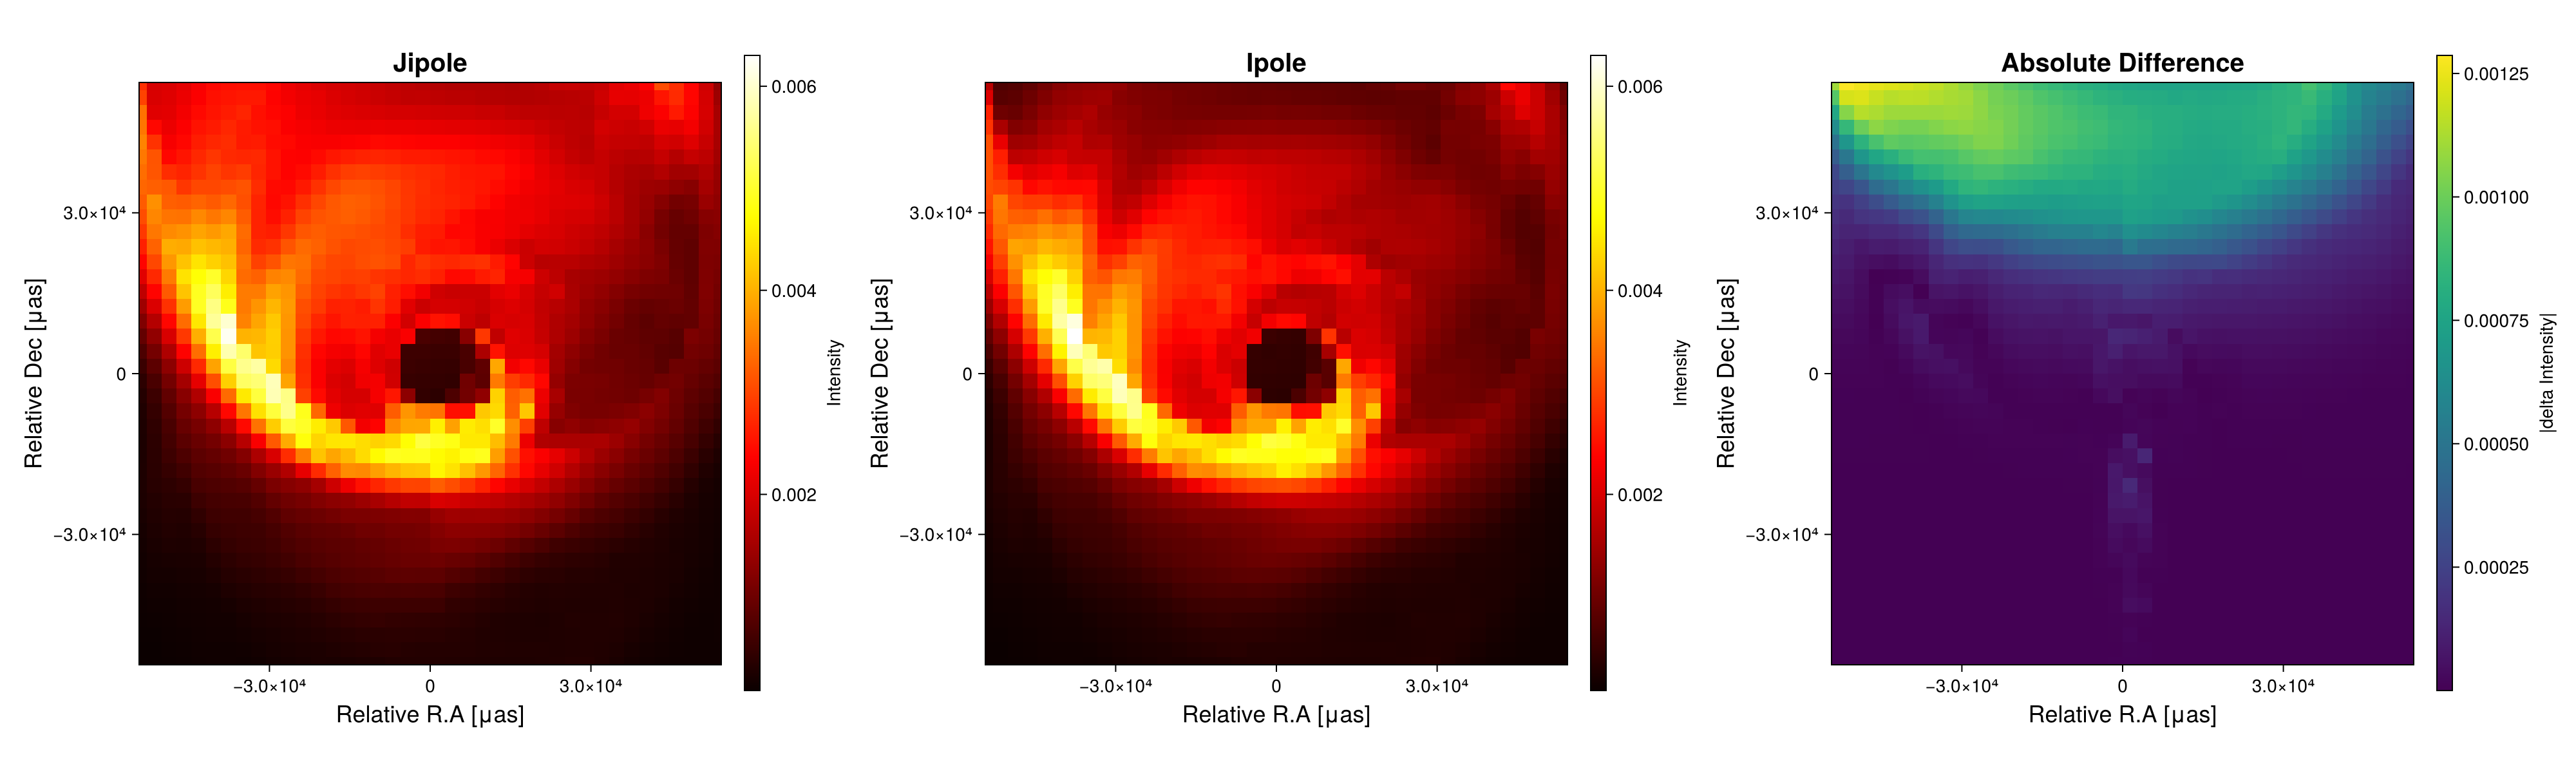

In [31]:
using CairoMakie
using Printf

# --- Example setup ---
img1 = Image
img2 = Image1

# Compute absolute difference
diff_img = abs.(img1 .- img2)

# Field of view & axes setup
d_kpc = 16.9
d_cm = d_kpc * 3.086e21
fov_rg = 30
half_fov_rg = fov_rg / 2
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

Ny, Nx = size(img1)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

# --- Figure ---
fig = Figure(size = (2000, 600))  # Wider to accommodate colorbars

# Common color scale for first two images
crange = extrema(vcat(img1[:], img2[:]))

# Panel 1: Image 1
ax1 = Axis(fig[1, 1],
    title = "Jipole",
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize = 18,
    ylabelsize = 18,
    titlesize = 20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)
hm1 = heatmap!(ax1, x, y, img1; colormap = :hot, colorrange = crange)
Colorbar(fig[1, 2], hm1; label = "Intensity", labelsize = 14)

# Panel 2: Image 2
ax2 = Axis(fig[1, 3],
    title = "Ipole",
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize = 18,
    ylabelsize = 18,
    titlesize = 20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)
hm2 = heatmap!(ax2, x, y, img2; colormap = :hot, colorrange = crange)
Colorbar(fig[1, 4], hm2; label = "Intensity", labelsize = 14)

# Panel 3: Absolute difference
ax3 = Axis(fig[1, 5],
    title = "Absolute Difference",
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize = 18,
    ylabelsize = 18,
    titlesize = 20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)
hm3 = heatmap!(ax3, x, y, diff_img; colormap = :viridis)
Colorbar(fig[1, 6], hm3; label = "|delta Intensity|", labelsize = 14)

fig